In [144]:
# Tạo đồ thị cho bài tập
with open('create_graphs.py', 'r', encoding='utf-8') as f:
    exec(f.read())

Đang tạo đồ thị...
Đã tạo dothi1.png
Đã tạo dothi2.png
Hoàn thành!


# Tìm kiếm trong không gian trạng thái

In [145]:
from PIL import Image
from IPython.display import display
image1 = Image.open("dothi1_real (1).png"); image2 = Image.open("dothi2_real (1).png");  # Đọc tập tin ảnh của đồ thị cần xử lý

## Bài 1. Biễu diễn đồ thị
Cho đồ thị hàm số **G** (**V**, **E**) như bên dưới:

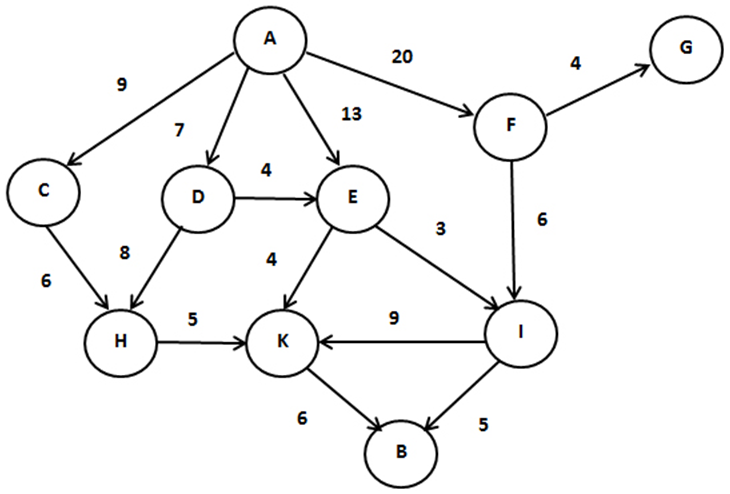

In [146]:
display(image1); # Hiển thị ảnh của đồ thị cần xử lý

### 1. Biễu diễn bằng danh sách kề có trọng số

In [147]:
COST = {}
COST["A"] = {"C": 9, "D": 7, "E": 13, "F": 20}
COST["B"] = {}
COST["C"] = {"H": 6}
COST["D"] = {"E": 4, "H": 8}
COST["E"] = {"I": 3, "K": 4}
COST["F"] = {"G": 4, "I": 6}
COST["G"] = {}
COST["H"] = {"K": 5}
COST["I"] = {"B": 5, "K": 9}
COST["K"] = {"B": 6}

In [148]:
import pprint
print(f'{pprint.pformat(COST)}')

{'A': {'C': 9, 'D': 7, 'E': 13, 'F': 20},
 'B': {},
 'C': {'H': 6},
 'D': {'E': 4, 'H': 8},
 'E': {'I': 3, 'K': 4},
 'F': {'G': 4, 'I': 6},
 'G': {},
 'H': {'K': 5},
 'I': {'B': 5, 'K': 9},
 'K': {'B': 6}}


### 2. Thao tác duyệt đồ thị

#### (a) Liệt kê các đỉnh

In [ ]:
print("Các đỉnh của đồ thị: ", end = " ")
# Hiển thị tất cả các đỉnh trong đồ thị
for vertex in COST.keys():
    print(vertex, end=" ")
print()

Các đỉnh của đồ thị:  A B C D E F G H I K 


#### (b) Liệt kê các cung
Hiển thị đồ thị dưới dạng danh sách kề có trọng số

In [150]:
def HienThiDoThi(G):
    """
    Hiển thị đồ thị G
    """
    # Duyệt qua tất cả các đỉnh và hiển thị danh sách kề
    for vertex in G:
        print(f"Đỉnh {vertex}: ", end="")
        if G[vertex]:  # Nếu có đỉnh kề
            for neighbor, weight in G[vertex].items():
                print(f"({vertex}->{neighbor}, {weight}) ", end="")
        else:
            print("Không có đỉnh kề", end="")
        print()  # Xuống dòng

In [151]:
print("Danh sách cung của đồ thị: ")
HienThiDoThi(COST)

Danh sách cung của đồ thị: 
Đỉnh A: (A->C, 9) (A->D, 7) (A->E, 13) (A->F, 20) 
Đỉnh B: Không có đỉnh kề
Đỉnh C: (C->H, 6) 
Đỉnh D: (D->E, 4) (D->H, 8) 
Đỉnh E: (E->I, 3) (E->K, 4) 
Đỉnh F: (F->G, 4) (F->I, 6) 
Đỉnh G: Không có đỉnh kề
Đỉnh H: (H->K, 5) 
Đỉnh I: (I->B, 5) (I->K, 9) 
Đỉnh K: (K->B, 6) 


#### (c) Kiểm tra kề và trọng số giữa 2 cung
Cho hai đỉnh A, B. Hỏi hai đỉnh A, B có kề nhau không? Nếu có, chi phí đi từ A tới B là bao nhiêu?

In [174]:
def LaKe(G, a, b):
    """
    Kiểm tra đỉnh a, b có kề nhau trong đồ thị G?
    Input: 
    + Đồ thị G
    + Cung (a, b)
    Return: (la_ke, trong_so)
    + (None, None): Đỉnh a, b không tồn tại
    + (0, None)   : Đỉnh a, b không kề nhau
    + (1, w): Đỉnh a, b kề nhau với w là trọng số của đồ thị G
    """
    result = None
    
    # Kiểm tra đỉnh a và b có tồn tại trong đồ thị không
    if a not in G or b not in G:
        result = (None, None)
    else:
        # Kiểm tra đỉnh b có kề với đỉnh a không
        if b in G[a]:
            weight = G[a][b]
            result = (1, weight)
        else:
            result = (0, None)
    
    return result

In [175]:
a = "L"; b = "R"; print(f"{a} ke {b}: {LaKe(COST, a, b)}")
a = "A"; b = "R"; print(f"{a} ke {b}: {LaKe(COST, a, b)}")
a = "E"; b = "D"; print(f"{a} ke {b}: {LaKe(COST, a, b)}")
a = "D"; b = "E"; print(f"{a} ke {b}: {LaKe(COST, a, b)}")

L ke R: (None, None)
A ke R: (None, None)
E ke D: (0, None)
D ke E: (1, 4)


#### (d) Tìm danh sách kề của một đỉnh
Cho một đỉnh A. Hỏi danh sách các đỉnh kề với A

In [154]:
def LayKe(G, a):
    """
    Tìm danh sách đỉnh kề với a trong đồ thị G
    Input: 
    + Đồ thị G và đỉnh A
    Return: danh sách kề 
    + None: a khong ton tai
    + []  : a khong ke voi bat ky dinh nao: 
    + [a1, a2, ...]: Danh sách đỉnh kề với a: 
    """
    result = None
    
    # Kiểm tra đỉnh a có tồn tại trong đồ thị không
    if a not in G:
        result = None
    else:
        # Tìm danh sách các đỉnh kề với a
        result = list(G[a].keys())
    
    return result

In [155]:
a = "P"; print(f"Danh sach ke voi dinh {a}: {LayKe(COST, a)}")
a = "A"; print(f"Danh sach ke voi dinh {a}: {LayKe(COST, a)}")
a = "B"; print(f"Danh sach ke voi dinh {a}: {LayKe(COST, a)}")
a = "D"; print(f"Danh sach ke voi dinh {a}: {LayKe(COST, a)}")

Danh sach ke voi dinh P: None
Danh sach ke voi dinh A: ['C', 'D', 'E', 'F']
Danh sach ke voi dinh B: []
Danh sach ke voi dinh D: ['E', 'H']


## Bài 2. Thuật toán Best-First Search

Thuật toán Best-First Search tìm đường đi ngắn nhất
```
OPEN: tập các trạng thái đã được sinh ra nhưng chưa được xét đến.
CLOSED: tập các trạng thái đã được xét đến.
COST(p, q): là khoảng cách giữa p, q.
g(p): khoảng cách từ trạng thái đầu đến trạng thái hiện tại p.
path(p): trạng thái trước đó để đi tới trạng thái p

Bước 1:
    Open    = {s}
    Close   = {}
Bước 2: while (Open !={})
    + Chọn trạng thái (đỉnh) tốt nhất p theo g(p) trong OPEN (xóa p khỏi OPEN).
    + Chuyển p qua CLOSED
    + Xét các đỉnh q kề với p:
        * Nếu q chưa có trong OPEN và CLOSED:
            - g(q) = g(p) + cost(p, q)
            - path(q) = p
            - Thêm q vào OPEN
        * Nếu q đã có trong OPEN và g(q) > g(p) + cost(p, q):
            - g(q) = g(p) + cost(p, q)
            - path(q) = p
        * Nếu q có trong CLOSED: không làm gì cả
Bước 3: Truy hồi trạng thái đích. 
```

### 1. Cài đặt thao tác trên tập Open

+ **Heap** là cấu trúc dữ liệu để biểu diễn hàng đợi ưu tiên để lấy giá trị nhỏ nhất (**MinHeap**), hay lớn nhất (**MaxHeap**) trong mảng 1 cách nhanh nhất.
+ Tập **OPEN** là chứa các giá trị đỉnh mà cần lấy đỉnh tốt nhất với gmin sao cho nhanh nhất. Do đó, ta tổ chức OPEN dưới dạng **HeapMin**.
+ Mỗi item trong **HeapMin** gồm 2 thông tin **(g, p)** với g là trọng số và p là đỉnh của đồ thị **G**.
+ Các thao tác trên Heap: 
    + **pusp(item)**: thêm 1 phần tử vào heap
    + **pop()**     : lấy phần tử nhỏ nhất ra khỏi heap
    + **top()**     : lấy giá trị phần tử nhỏ nhất của heap
    + **empty()**   : kiểm tra heap rỗng

In [ ]:
import heapq # Thư viện Python hỗ trợ push, pop, pushpop để xây dựng heap trên 1 mảng
# Xây dựng MinHeap
# module heapq sẽ tự động sắp xếp phần tử nhỏ nhất của heap đứng đầu tiên để thuận tiện cho pop và push
class MinHeap(object):
    def __init__(self):                         # Khởi tạo MinHeap rỗng
        self.items = []
        pass
    
    def empty(self):                            # Kiểm tra heap rỗng
        return len(self.items)==0
  
    def push(self, item):                       # Đưa một item vào MinHeap
        heapq.heappush(self.items, item)
        pass
  
    def pop(self):                              # Lấy 1 item có giá trị nhỏ nhất ra khỏi MinHeap
        item = heapq.heappop(self.items)
        return item
    
    def check(self, item):                      # Kiểm tra item có nằm trong MinHeap
        return item in self.items
    
    def update(self, item, new_item):           # Cập nhật lại new_item từ item cho trước
        for i in range(len(self.items)):
            if self.items[i] == item:
                self.items[i] = new_item
                heapq.heapify(self.items) # heapify sẽ làm danh sách sau khi cập nhật thành 1 min_heap đúng bản chất 
        pass
  
    pass # MinHeap

In [ ]:
items = [(10, "F"), (6, "B"), (8, "K"), (21, "A"), (9, "H")]

# Thêm danh sách items gồm (g = giá trị ngắn nhất từ start --> p, p --> thông tin đỉnh p) vào OPEN
OPEN = MinHeap()
print("Thứ tự thêm vào: ")
for item in items: 
    OPEN.push(item)
    print(item, end = " ")
print()

OPEN.update((8, 'K'), (1, 'K')) # cấu trúc của update(item hiện tại cần đổi , item sau khi đổi )

print("Thứ tự lấy ra: ")
while OPEN.empty() == False:
    print(OPEN.pop(), end = " ")

Thứ tự thêm vào: 
(10, 'F') (6, 'B') (8, 'K') (21, 'A') (9, 'H') 
Thứ tự lấy ra: 
(1, 'K') (6, 'B') (9, 'H') (10, 'F') (21, 'A') 

### 2. Cài đặt thuật toán

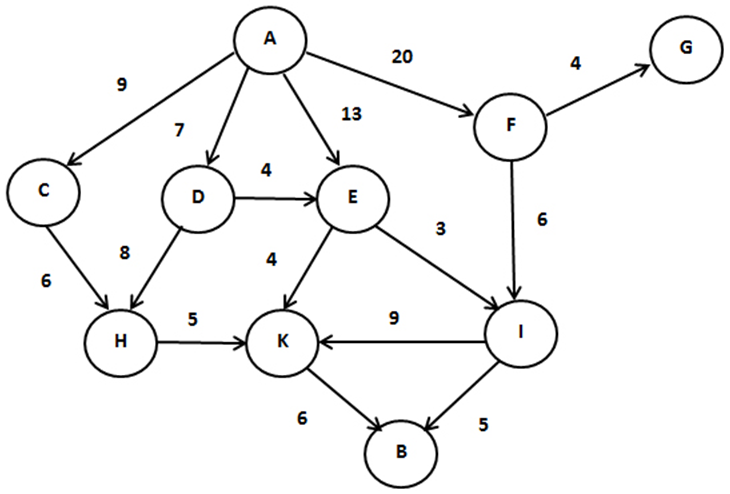

In [158]:
display(image1)

In [159]:
def BestFirstSearch(G, start, goal):
    """
    Tìm đường đi ngắn nhất từ đỉnh start đến goal trong đồ thị G
    Input:
    + Đồ thị G biểu diễn dưới dạng danh sách kề trọng số
    + Đỉnh xuất phát start và tìm kiểm goal
    Return: (path, g) 
    + path[q]: mảng chứa các đỉnh phía trước để đi tới q
    + g[q]: mảng chứa đường đi ngắn nhất từ start đến q
    + (None, None) --> đỉnh start, goal không hợp lệ
    Lưu ý: 
    + Do OPEN là MinHeap nên ta tổ chức dạng (trọng số, đỉnh) để sắp xếp tăng dần trọng số, cũng như lấy được đỉnh
      * Khi đó, thao tác lấy 1 đỉnh với trọng số nhỏ nhất là (trọng số, đỉnh) = OPEN.pop()
      * Ngược lại kiểm tra 1 đỉnh có nằm trong OPEN thì có 2 cách:
        (1) Cách trực tiếp: dùng hàm check với (g(đỉnh), đỉnh) để kiểm tra
        (2) Cách gián tiếp: g.get(đỉnh) is not None ==> đã thấy (trong OPEN hay CLOSED) và đỉnh not in CLOSED
    """
    result = (None, None)
    
    if G.get(start) is None or G.get(goal) is None:
        result = (None, None)
    else:
        path     = {}     # path(q) = p nghĩa là đỉnh p là đỉnh trước của q, nếu là None nghĩa là ko có đỉnh trước
        g        = {}     # g(q) = d nghĩa là khoảng cách ngắn nhất từ start --> q là d
        OPEN     = MinHeap()
        CLOSED   = []
        
        OPEN.push((0, start))               # đưa đỉnh start vào OPEN (0 là chi phí của start)
        path[start] = None                  # trước start không có đỉnh nào
        g[start]    = 0                     # chi phí là 0
        while OPEN.empty() == False:
            # Lấy đỉnh có g(p) nhỏ nhất ra khỏi OPEN
            (current_g, p) = OPEN.pop()
            CLOSED.append(p)
            
            # Nếu tìm thấy đích
            if p == goal:
                break
                
            # Duyệt các đỉnh kề của p
            for q in G[p]:
                cost_pq = G[p][q]  # Chi phí từ p đến q
                new_g = g[p] + cost_pq  # Chi phí mới từ start đến q
                
                # Nếu q chưa được thăm (chưa có trong g)
                if q not in g:
                    g[q] = new_g
                    path[q] = p
                    OPEN.push((new_g, q))
                # Nếu q đã có trong OPEN và tìm thấy đường tốt hơn
                elif q not in CLOSED and new_g < g[q]:
                    # Cập nhật đường đi tốt hơn
                    OPEN.update((g[q], q), (new_g, q))
                    g[q] = new_g
                    path[q] = p
            
            pass # while
        result = (path, g)
        pass # if 
    return result
    pass # BestFirstSearch

In [160]:
path, g = BestFirstSearch(COST, 'A', 'B')
print(f'Mảng tối ưu:\n{pprint.pformat(g)}\n')
print(f'Mảng truy hồi đường:\n{pprint.pformat(path)}\n')

Mảng tối ưu:
{'A': 0, 'B': 19, 'C': 9, 'D': 7, 'E': 11, 'F': 20, 'H': 15, 'I': 14, 'K': 15}

Mảng truy hồi đường:
{'A': None,
 'B': 'I',
 'C': 'A',
 'D': 'A',
 'E': 'D',
 'F': 'A',
 'H': 'D',
 'I': 'E',
 'K': 'E'}



## Bài 3. Thuật toán A*

```
OPEN: tập các trạng thái đã được sinh ra nhưng chưa được xét đến.
CLOSED: tập các trạng thái đã được xét đến.
COST(p, q): là khoảng cách giữa p, q.
g(p): khoảng cách từ trạng thái đầu đến trạng thái hiện tại p.
h(p): giá trị được lượng giá từ trạng thái hiện tại đến trạng thái đích.
f(p) = g(p) + h(p)
path(p): trạng thái trước đó để đi tới trạng thái p

Bước 1:
    Open    = {s}
    Close   = {}
Bước 2: while (Open !={})
    + Chọn trạng thái (đỉnh) tốt nhất p theo g(p) trong OPEN (xóa p khỏi OPEN).
    + Chuyển p qua CLOSED
    + Xét các đỉnh q kề với p:
        * Nếu q chưa có trong OPEN:
            - g(q) = g(p) + cost(p, q)
            - f(q) = g(q) + h(q)
            - path(q) = p
            - Thêm q vào OPEN
        * Nếu q đã có trong OPEN và g(q) > g(p) + cost(p, q):
            - g(q) = g(p) + cost(p, q)
            - f(q) = g(q) + h(q)
            - path(q) = p
        * Nếu q có trong CLOSED và g(q) > g(p) + cost(p, q):
            - g(q) = g(p) + cost(p, q)
            - f(q) = g(q) + h(q)
            - path(q) = p
            - Di chuyển q vào CLOSED
Bước 3: Truy hồi trạng thái đích. 
```

### 1. Biểu diễn tri thức h(p)

Thuật toán **A*** tìm đường đi ngắn nhất khi cho tri thức **h(goal)**

Nghĩa là, tại một đỉnh p đang xét, ta cần cân nhắc:
+ Chi phí tối ưu hiện tại từ start --> đỉnh đang xét **g(p)**
+ Ước lượng tương lai từ đỉnh đang xét --> đỉnh muốn đến **h(p)**

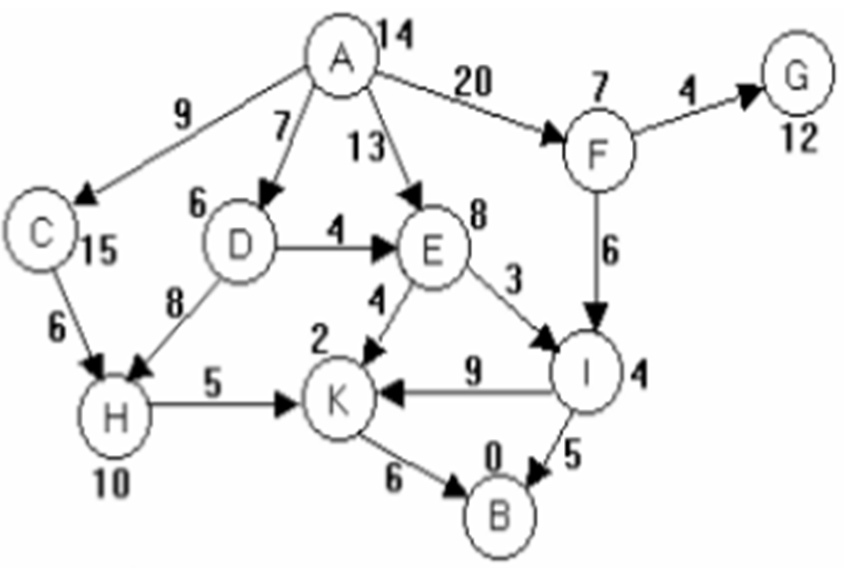

In [161]:
display(image2)

In [162]:
# Biễu diễn tri thức h(p) ước lượng chi phí từ p --> đỉnh "B" 
# Ước lượng cho thuật toán khả thi là phải luôn nhỏ hơn đường đi ngắn nhất thực tế từ p --> đỉnh "B"
h = {}                   # từ điển chứ các đỉnh trong đồ thị với giá trị là biểu diễn tri thức
h["A"] = 15              # chi phí ước lượng từ A --> B 
h["B"] = 0               # Đích là B nên h(B) = 0
h["C"] = 12              # Ước lượng từ C --> B
h["D"] = 10              # Ước lượng từ D --> B  
h["E"] = 8               # Ước lượng từ E --> B
h["F"] = 14              # Ước lượng từ F --> B
h["G"] = 16              # Ước lượng từ G --> B
h["H"] = 6               # Ước lượng từ H --> B
h["I"] = 5               # Ước lượng từ I --> B
h["K"] = 6               # Ước lượng từ K --> B

In [163]:
print(f'{pprint.pformat(h)}')

{'A': 15,
 'B': 0,
 'C': 12,
 'D': 10,
 'E': 8,
 'F': 14,
 'G': 16,
 'H': 6,
 'I': 5,
 'K': 6}


### 2. Cài đặt thuật toán

In [164]:
def AStartSearch(G, start, goal, h = {}):
    """
    Tìm đường đi ngắn nhất từ đỉnh start đến goal trong đồ thị G với tri thức h(p)
    Input:
    + Đồ thị G biểu diễn dưới dạng danh sách kề trọng số
    + Đỉnh xuất phát start và tìm kiểm goal
    + Tri thức h(p) nghĩa là ước lượng chi phí đi từ đỉnh p --> goal
    Return: (path, g) 
    + path[q]: mảng chứa các đỉnh phía trước để đi tới q
    + g[q]: mảng chứa đường đi ngắn nhất từ start đến q
    + (None, None) --> đỉnh start, goal không hợp lệ
    Lưu ý: 
    + Do OPEN là MinHeap nên ta tổ chức dạng (trọng số, đỉnh) để sắp xếp tăng dần trọng số, cũng như lấy được đỉnh
      * Khi đó, thao tác lấy 1 đỉnh với trọng số nhỏ nhất là (trọng số, đỉnh) = OPEN.pop()
      * Ngược lại kiểm tra 1 đỉnh có nằm trong OPEN thì có 2 cách:
        (1) Cách trực tiếp: dùng hàm check với (g(đỉnh), đỉnh) để kiểm tra
        (2) Cách gián tiếp: g.get(đỉnh) is not None ==> đã thấy (trong OPEN hay CLOSED) và đỉnh not in CLOSED
    """
    result = (None, None)
    
    if G.get(start) is None or G.get(goal) is None:
        result = (None, None)
    else:
        path     = {}     # path(q) = p nghĩa là đỉnh p là đỉnh trước của q, nếu là None nghĩa là ko có đỉnh trước
        g        = {}     # g(q) = d nghĩa là khoảng cách ngắn nhất từ start --> q là d
        f        = {}     # f(p) = g(p) + h(p), h(p) = None ==> h(p) = 0 (không có tri thức từ p --> goal)
        OPEN     = MinHeap()
        CLOSED   = []
        
        path[start] = None                        # trước start không có đỉnh nào
        g[start]    = 0                           # chi phí là 0
        f[start]    = g[start] + h.get(start, 0)  # nếu 1 đỉnh ko có trong h --> tri thức chưa có --> h = 0
        OPEN.push((f[start], start))              # đưa đỉnh start vào OPEN với chi phí f(start)
        while OPEN.empty() == False:
            (_, p) = OPEN.pop()                   # lấy đỉnh p ra khỏi OPEN với f(p) min
            CLOSED.append(p)                      # đưa p vào CLOSED
            
            # Nếu tìm thấy đích
            if p == goal:
                break
                
            # Duyệt các đỉnh kề của p
            for q in G[p]:
                cost_pq = G[p][q]  # Chi phí từ p đến q
                new_g = g[p] + cost_pq  # Chi phí mới từ start đến q
                new_f = new_g + h.get(q, 0)  # f(q) = g(q) + h(q)
                
                # Nếu q chưa được thăm (chưa có trong g)
                if q not in g:
                    g[q] = new_g
                    f[q] = new_f
                    path[q] = p
                    OPEN.push((new_f, q))
                # Nếu q đã có trong OPEN và tìm thấy đường tốt hơn
                elif q not in CLOSED and new_g < g[q]:
                    # Cập nhật đường đi tốt hơn
                    OPEN.update((f[q], q), (new_f, q))
                    g[q] = new_g
                    f[q] = new_f
                    path[q] = p
                # Nếu q đã có trong CLOSED và tìm thấy đường tốt hơn
                elif q in CLOSED and new_g < g[q]:
                    g[q] = new_g
                    f[q] = new_f
                    path[q] = p
                    # Di chuyển q trở lại OPEN
                    CLOSED.remove(q)
                    OPEN.push((new_f, q))
            
        result = (path, g)
    
    return result

In [165]:
path, g = AStartSearch(COST, 'A', 'B')
print(f'Mảng tối ưu:\n{pprint.pformat(g)}\n')
print(f'Mảng truy hồi đường:\n{pprint.pformat(path)}\n')

Mảng tối ưu:
{'A': 0, 'B': 19, 'C': 9, 'D': 7, 'E': 11, 'F': 20, 'H': 15, 'I': 14, 'K': 15}

Mảng truy hồi đường:
{'A': None,
 'B': 'I',
 'C': 'A',
 'D': 'A',
 'E': 'D',
 'F': 'A',
 'H': 'D',
 'I': 'E',
 'K': 'E'}



### 3. Truy hồi đường đi

In [166]:
def find_path(path, start, goal):
    """
    Cho mang truy hoi duong, tim ds dinh tu start --> goal
    """
    result = []
    
    # Kiểm tra goal có tồn tại trong path không
    if goal not in path:
        return result  # Không có đường đi
        
    # Truy hồi ngược từ goal về start
    current = goal
    while current is not None:
        result.append(current)
        current = path[current]
    
    # Đảo ngược để có đường đi từ start --> goal
    result.reverse()
    
    return result
    pass

In [167]:
find_path(path, 'A', 'B')

['A', 'D', 'E', 'I', 'B']

# Bài 4. Bài toán mê cung 

Tìm đường đi từ vị trí bắt đầu đến vị trí đích trong mê cung với các chướng ngại vật.

Mê cung đã được tạo:
Kích thước: (8, 9)
Điểm bắt đầu: (1, 1)
Điểm đích: (1, 7)


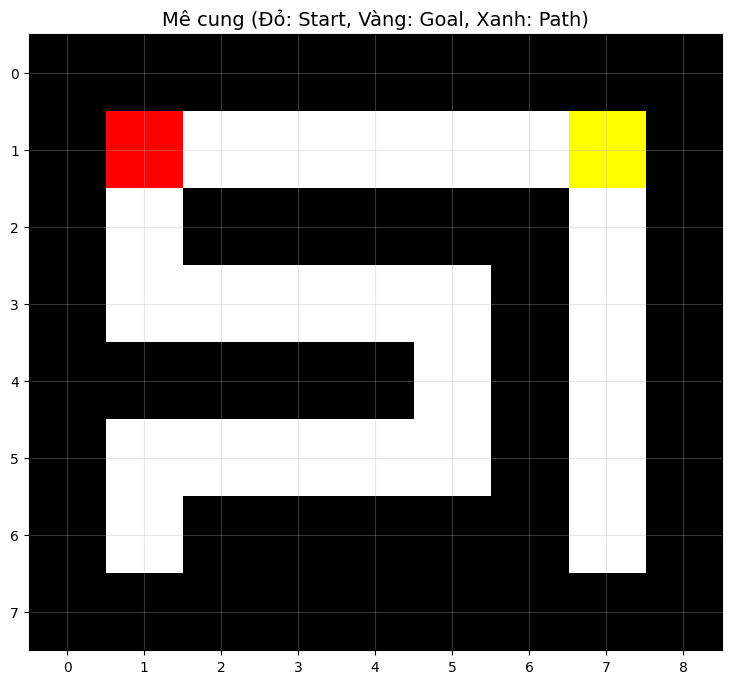


Cấu trúc mê cung:
0: #########
1: #S     G#
2: # ##### #
3: #     # #
4: ##### # #
5: #     # #
6: # ##### #
7: #########


In [168]:
import numpy as np
import matplotlib.pyplot as plt

def create_maze_from_file(filename):
    """Tạo mê cung từ file text"""
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.read().strip().split('\n')
        
        # Chuyển đổi ký tự thành số
        maze = []
        start = None
        goal = None
        
        # Tìm độ dài tối đa
        max_length = max(len(line) for line in lines)
        
        for i, line in enumerate(lines):
            row = []
            # Đảm bảo mỗi hàng có cùng độ dài bằng cách thêm tường vào cuối
            line_padded = line.ljust(max_length, '#')
            
            for j, char in enumerate(line_padded):
                if char == '#':  # Tường
                    row.append(1)
                elif char == ' ':  # Đường đi
                    row.append(0)
                elif char == 'S':  # Điểm bắt đầu
                    row.append(0)
                    start = (i, j)
                elif char == 'G':  # Điểm đích
                    row.append(0)
                    goal = (i, j)
                else:
                    row.append(0)
            maze.append(row)
            
    except FileNotFoundError:
        # Tạo mê cung mẫu nếu không có file
        maze = [
            [1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 1, 0, 0, 1],
            [1, 0, 1, 0, 1, 0, 1, 1],
            [1, 0, 1, 0, 0, 0, 0, 1],
            [1, 0, 1, 1, 1, 1, 0, 1],
            [1, 0, 0, 0, 0, 1, 0, 1],
            [1, 1, 1, 1, 0, 0, 0, 1],
            [1, 1, 1, 1, 1, 1, 1, 1]
        ]
        start = (1, 1)
        goal = (6, 6)
    
    return np.array(maze), start, goal

def visualize_maze(maze, path=None, start=None, goal=None):
    """Hiển thị mê cung với đường đi (nếu có)"""
    plt.figure(figsize=(10, 8))
    
    # Tạo màu cho mê cung
    colored_maze = np.zeros((maze.shape[0], maze.shape[1], 3))
    
    # Tường - màu đen
    colored_maze[maze == 1] = [0, 0, 0]
    # Đường đi - màu trắng
    colored_maze[maze == 0] = [1, 1, 1]
    
    # Đường đi tìm được - màu xanh lá
    if path:
        for pos in path:
            if pos != start and pos != goal:
                colored_maze[pos[0], pos[1]] = [0, 1, 0]
    
    # Điểm bắt đầu - màu đỏ
    if start:
        colored_maze[start[0], start[1]] = [1, 0, 0]
    
    # Điểm đích - màu vàng
    if goal:
        colored_maze[goal[0], goal[1]] = [1, 1, 0]
    
    plt.imshow(colored_maze)
    plt.title('Mê cung (Đỏ: Start, Vàng: Goal, Xanh: Path)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

# Tạo file mê cung mẫu có đường đi rõ ràng 
maze_content = """########
#S     G#
# ##### #
#     # #
##### # #
#     # #
# ##### #
########"""

with open('mecung.txt', 'w', encoding='utf-8') as f:
    f.write(maze_content)

# Đọc mê cung từ file
maze, start, goal = create_maze_from_file('mecung.txt')
print("Mê cung đã được tạo:")
print(f"Kích thước: {maze.shape}")
print(f"Điểm bắt đầu: {start}")
print(f"Điểm đích: {goal}")

# Hiển thị mê cung
visualize_maze(maze, start=start, goal=goal)

# In cấu trúc mê cung để debug
print("\nCấu trúc mê cung:")
for i, row in enumerate(maze):
    line = ""
    for j, cell in enumerate(row):
        if (i, j) == start:
            line += "S"
        elif (i, j) == goal:
            line += "G"
        elif cell == 1:
            line += "#"
        else:
            line += " "
    print(f"{i}: {line}")

Đường đi tìm được: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7)]
Số bước: 6


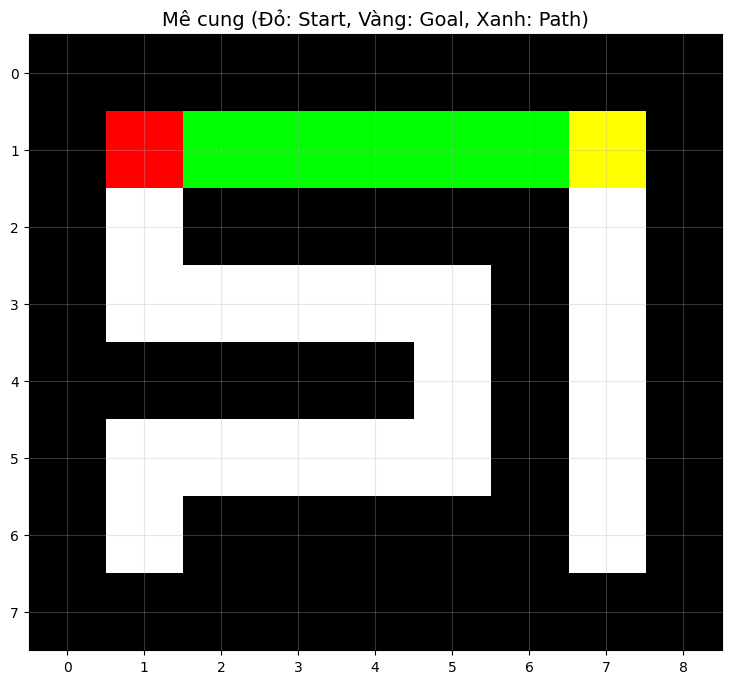

In [ ]:
def manhattan_distance(pos1, pos2):
    # Tính khoảng cách Manhattan giữa 2 điểm
    return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

def get_neighbors(maze, pos):
    """Lấy các vị trí kề hợp lệ"""
    neighbors = []
    rows, cols = maze.shape
    
    # 4 hướng: lên, xuống, trái, phải
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    for dr, dc in directions:
        new_row, new_col = pos[0] + dr, pos[1] + dc
        
        # Kiểm tra biên và không phải tường
        if (0 <= new_row < rows and 0 <= new_col < cols and 
            maze[new_row, new_col] == 0):
            neighbors.append((new_row, new_col))
    
    return neighbors

def astar_maze(maze, start, goal):
    # Giải mê cung bằng thuật toán A*
    from heapq import heappush, heappop
    
    # Khởi tạo
    open_set = []
    heappush(open_set, (0, start))
    
    came_from = {}
    g_score = {start: 0}
    f_score = {start: manhattan_distance(start, goal)}
    
    while open_set:
        current = heappop(open_set)[1]
        
        if current == goal:
            # Truy hồi đường đi
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]  # Đảo ngược
        
        for neighbor in get_neighbors(maze, current):
            tentative_g = g_score[current] + 1  # Chi phí = 1 cho mỗi bước
            
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + manhattan_distance(neighbor, goal)
                heappush(open_set, (f_score[neighbor], neighbor))
    
    return []  # Không tìm thấy đường

# Giải mê cung
path = astar_maze(maze, start, goal)
print(f"Đường đi tìm được: {path}")
print(f"Số bước: {len(path) - 1}")

# Hiển thị kết quả
visualize_maze(maze, path, start, goal)

# Bài 5. Bài toán 8-Puzzle

Bài toán xếp số từ 1-8 trong lưới 3x3 với một ô trống để đạt được trạng thái đích.

In [ ]:
class PuzzleState:
    # Lớp biểu diễn trạng thái của puzzle 8
    
    def __init__(self, board):
        self.board = tuple(tuple(row) for row in board)
        self.size = len(board)
        
    def __eq__(self, other):
        return self.board == other.board
    
    def __hash__(self):
        return hash(self.board)
    
    def __lt__(self, other):
        return False  # Để sử dụng với heapq
    
    def find_blank(self):
        """Tìm vị trí ô trống (số 0)"""
        for i in range(self.size):
            for j in range(self.size):
                if self.board[i][j] == 0:
                    return (i, j)
        return None
    
    def get_neighbors(self):
        # Lấy tất cả trạng thái kề có thể đạt được
        neighbors = []
        blank_pos = self.find_blank()
        blank_row, blank_col = blank_pos
        
        # 4 hướng di chuyển: lên, xuống, trái, phải
        moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        
        for dr, dc in moves:
            new_row = blank_row + dr
            new_col = blank_col + dc
            
            # Kiểm tra biên
            if 0 <= new_row < self.size and 0 <= new_col < self.size:
                # Tạo bảng mới bằng cách hoán đổi ô trống với ô kế bên
                new_board = [list(row) for row in self.board]
                new_board[blank_row][blank_col] = new_board[new_row][new_col]
                new_board[new_row][new_col] = 0
                
                neighbors.append(PuzzleState(new_board))
        
        return neighbors
    
    def display(self):
        # Hiển thị trạng thái puzzle
        for row in self.board:
            print(' '.join('_' if x == 0 else str(x) for x in row))
        print()

def manhattan_heuristic(state, goal):
    #Heuristic Manhattan distance cho 8-puzzle
    distance = 0
    goal_positions = {}
    
    # Tạo từ điển vị trí đích cho mỗi số
    for i in range(goal.size):
        for j in range(goal.size):
            if goal.board[i][j] != 0:
                goal_positions[goal.board[i][j]] = (i, j)
    
    # Tính tổng khoảng cách Manhattan
    for i in range(state.size):
        for j in range(state.size):
            if state.board[i][j] != 0:
                value = state.board[i][j]
                if value in goal_positions:
                    goal_i, goal_j = goal_positions[value]
                    distance += abs(i - goal_i) + abs(j - goal_j)
    
    return distance

# Tạo trạng thái đầu và trạng thái đích
initial_board = [
    [1, 2, 3],
    [4, 0, 6],
    [7, 5, 8]
]

goal_board = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 0]
]

initial_state = PuzzleState(initial_board)
goal_state = PuzzleState(goal_board)

print("Trạng thái ban đầu:")
initial_state.display()

print("Trạng thái đích:")
goal_state.display()

print(f"Heuristic của trạng thái ban đầu: {manhattan_heuristic(initial_state, goal_state)}")

Trạng thái ban đầu:
1 2 3
4 _ 6
7 5 8

Trạng thái đích:
1 2 3
4 5 6
7 8 _

Heuristic của trạng thái ban đầu: 2


In [ ]:
def astar_puzzle(initial, goal):
   
   # Giải 8-puzzle bằng thuật toán A*
    from heapq import heappush, heappop
    
    # Kiểm tra trạng thái ban đầu đã là đích chưa
    if initial == goal:
        return [initial]
    
    # Khởi tạo
    open_set = []
    heappush(open_set, (0, 0, initial))  # (f_score, g_score, state)
    
    came_from = {}
    g_score = {initial: 0}
    closed_set = set()
    
    nodes_expanded = 0
    
    while open_set:
        current_f, current_g, current_state = heappop(open_set)
        
        if current_state in closed_set:
            continue
            
        closed_set.add(current_state)
        nodes_expanded += 1
        
        if current_state == goal:
            # Truy hồi đường đi
            path = []
            state = current_state
            while state in came_from:
                path.append(state)
                state = came_from[state]
            path.append(initial)
            
            print(f"Tìm thấy nghiệm sau {nodes_expanded} bước mở rộng")
            return path[::-1]  # Đảo ngược
        
        # Duyệt các trạng thái kề
        for neighbor in current_state.get_neighbors():
            if neighbor in closed_set:
                continue
                
            tentative_g = current_g + 1
            
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current_state
                g_score[neighbor] = tentative_g
                h_score = manhattan_heuristic(neighbor, goal)
                f_score = tentative_g + h_score
                
                heappush(open_set, (f_score, tentative_g, neighbor))
    
    print("Không tìm thấy nghiệm")
    return []

# Giải puzzle
solution_path = astar_puzzle(initial_state, goal_state)

if solution_path:
    print(f"Số bước di chuyển: {len(solution_path) - 1}")
    print("\\nCác bước giải:")
    for i, state in enumerate(solution_path):
        print(f"Bước {i}:")
        state.display()
else:
    print("Không có nghiệm")

Tìm thấy nghiệm sau 3 bước mở rộng
Số bước di chuyển: 2
\nCác bước giải:
Bước 0:
1 2 3
4 _ 6
7 5 8

Bước 1:
1 2 3
4 5 6
7 _ 8

Bước 2:
1 2 3
4 5 6
7 8 _



# Bài 6. Thuật toán A^KT 

Thuật toán A* cải tiến với việc sử dụng tri thức từ các lời giải trước đó để tăng hiệu quả tìm kiếm.

In [172]:
class AStarKT:
    def __init__(self):
        self.knowledge_base = {}  # Lưu trữ tri thức
        self.pattern_database = {}  # Cơ sở dữ liệu mẫu
    
    def store_solution_pattern(self, pattern_key, cost):
        """Lưu mẫu giải quyết vào cơ sở tri thức"""
        self.pattern_database[pattern_key] = cost
    
    def enhanced_heuristic(self, state, goal, base_heuristic):
        """
        Heuristic cải tiến với tri thức từ cơ sở dữ liệu
        """
        # Heuristic cơ bản
        h_base = base_heuristic(state, goal)
        
        # Bonus từ tri thức đã học
        h_bonus = 0
        
        # Kiểm tra các mẫu đã biết
        state_pattern = self.extract_pattern(state)
        if state_pattern in self.pattern_database:
            h_bonus = self.pattern_database[state_pattern] * 0.1
        
        return h_base + h_bonus
    
    def extract_pattern(self, state):
        """Trích xuất mẫu từ trạng thái (ví dụ: corner positions)"""
        # Đơn giản: lấy vị trí của một số góc
        if hasattr(state, 'board'):
            return (state.board[0][0], state.board[0][2], 
                   state.board[2][0], state.board[2][2])
        return None
    
    def astar_with_kt(self, initial, goal, base_heuristic):
        """
        A* với Knowledge Transfer
        """
        from heapq import heappush, heappop
        
        if initial == goal:
            return [initial]
        
        open_set = []
        heappush(open_set, (0, 0, initial))
        
        came_from = {}
        g_score = {initial: 0}
        closed_set = set()
        nodes_expanded = 0
        
        while open_set:
            current_f, current_g, current_state = heappop(open_set)
            
            if current_state in closed_set:
                continue
                
            closed_set.add(current_state)
            nodes_expanded += 1
            
            if current_state == goal:
                # Lưu tri thức từ lời giải này
                path = []
                state = current_state
                while state in came_from:
                    pattern = self.extract_pattern(state)
                    if pattern:
                        self.store_solution_pattern(pattern, g_score[state])
                    path.append(state)
                    state = came_from[state]
                path.append(initial)
                
                print(f"A^KT: Tìm thấy nghiệm sau {nodes_expanded} bước mở rộng")
                return path[::-1]
            
            for neighbor in current_state.get_neighbors():
                if neighbor in closed_set:
                    continue
                    
                tentative_g = current_g + 1
                
                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current_state
                    g_score[neighbor] = tentative_g
                    
                    # Sử dụng heuristic cải tiến
                    h_score = self.enhanced_heuristic(neighbor, goal, base_heuristic)
                    f_score = tentative_g + h_score
                    
                    heappush(open_set, (f_score, tentative_g, neighbor))
        
        return []

# So sánh A* thông thường và A* với KT
print("=== So sánh hiệu suất ===")

# A* thông thường
solution_normal = astar_puzzle(initial_state, goal_state)

# A* với Knowledge Transfer
kt_solver = AStarKT()
solution_kt = kt_solver.astar_with_kt(initial_state, goal_state, manhattan_heuristic)

print(f"\\nA* thông thường: {len(solution_normal)-1 if solution_normal else 0} bước")
print(f"A* với KT: {len(solution_kt)-1 if solution_kt else 0} bước")

=== So sánh hiệu suất ===
Tìm thấy nghiệm sau 3 bước mở rộng
A^KT: Tìm thấy nghiệm sau 3 bước mở rộng
\nA* thông thường: 2 bước
A* với KT: 2 bước


# Bài 7. Visualization với NetworkX

Sử dụng thư viện NetworkX để trực quan hóa các thuật toán tìm kiếm.

=== Visualization với Best-First Search ===


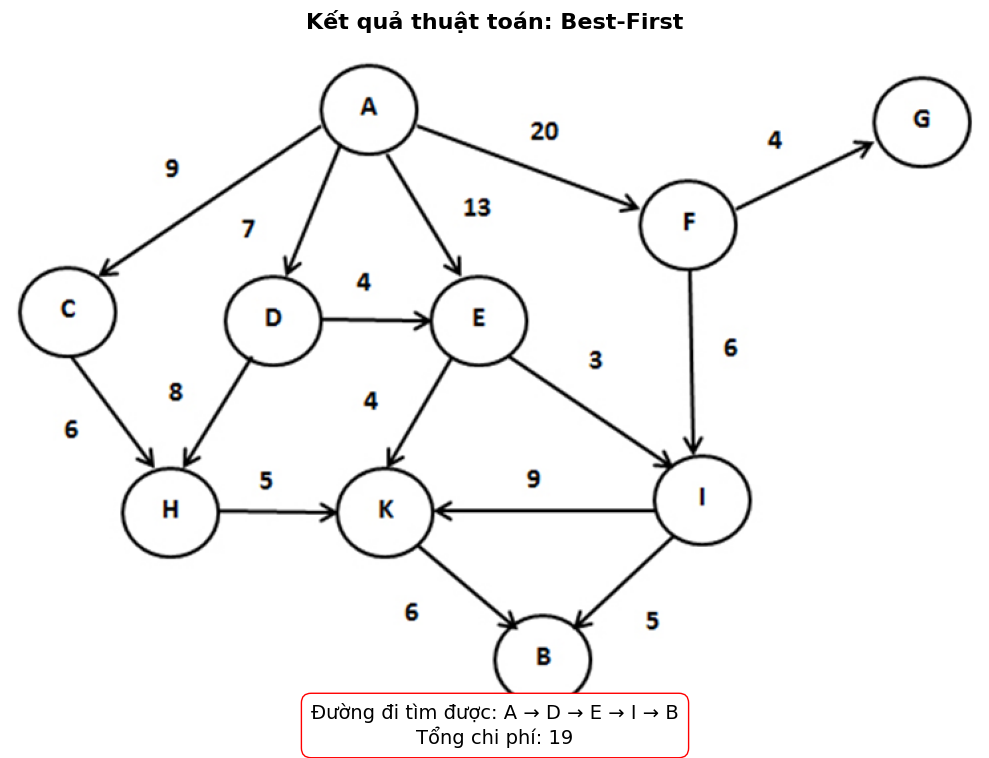


=== Visualization với A* ===


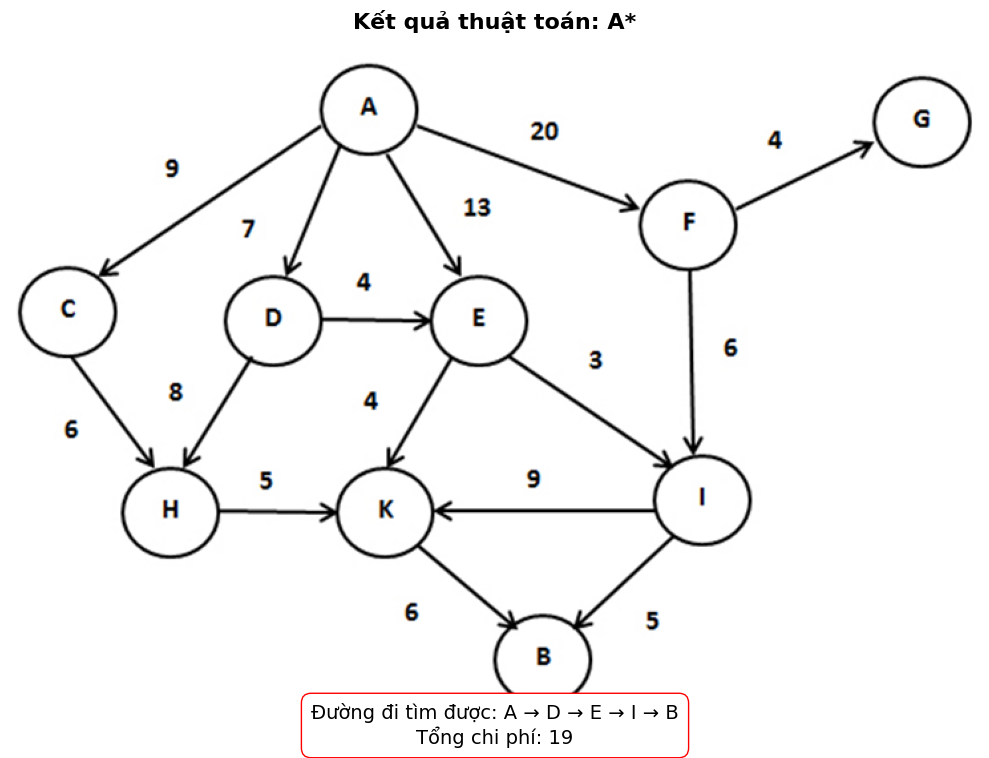


So sánh kết quả:
Chi phí Best-First: 19
Chi phí A*: 19


In [173]:
import networkx as nx
import matplotlib.pyplot as plt
from PIL import Image

def visualize_graph_search(graph_dict, start, goal, algorithm="A*", background_image=None):
    """
    Trực quan hóa quá trình tìm kiếm:
    - Nếu có background_image: Hiển thị ảnh gốc và ghi chú đường đi tìm được.
    - Nếu không: Vẽ lại bằng NetworkX (như cũ).
    """
    
    #chạy thuật toán để tìm đường đi
    if algorithm == "Best-First":
        path_dict, g_values = BestFirstSearch(graph_dict, start, goal)
    else:  # A*
        try:
            path_dict, g_values = AStartSearch(graph_dict, start, goal, h)
        except NameError:
            print("Cảnh báo: Biến 'h' chưa được định nghĩa.")
            path_dict, g_values = AStartSearch(graph_dict, start, goal, {})
    
    # Tìm danh sách các đỉnh trong đường đi
    path_nodes = []
    if path_dict and goal in path_dict:
        path_nodes = find_path(path_dict, start, goal)
    
    cost = g_values[goal] if g_values and goal in g_values else "N/A"
    
    plt.figure(figsize=(10, 8))
    
    if background_image:
        # Hiển thị ảnh gốc
        plt.imshow(background_image)
        plt.axis('off') # Tắt trục tọa độ
        
        # Tiêu đề và kết quả
        title_text = f"Kết quả thuật toán: {algorithm}"
        plt.title(title_text, fontsize=16, fontweight='bold', pad=20)
        
        if path_nodes:
            # Hiển thị đường đi và chi phí ra một khung text
            result_text = f"Đường đi tìm được: {' → '.join(path_nodes)}\nTổng chi phí: {cost}"
            plt.figtext(0.5, 0.05, result_text, ha="center", fontsize=14, 
                        bbox={"facecolor":"white", "edgecolor":"red", "boxstyle":"round,pad=0.5"})
        else:
            plt.figtext(0.5, 0.05, "Không tìm thấy đường đi", ha="center", fontsize=14, color="red")
            
    else:
        # Fallback: Vẽ bằng NetworkX nếu không có ảnh nền
        G = nx.DiGraph()
        for node, neighbors in graph_dict.items():
            for neighbor, weight in neighbors.items():
                G.add_edge(node, neighbor, weight=weight)
        
        pos = nx.spring_layout(G, k=0.8, seed=42)
        nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800)
        # ... (giản lược phần vẽ NetworkX để tập trung vào yêu cầu chính)
        plt.title(f"Mô phỏng đồ thị (Không có ảnh gốc)\nĐường đi: {path_nodes}")

    plt.tight_layout()
    plt.show()
    
    return path_dict, g_values

# Sửa lại phần gọi hàm để truyền ảnh vào
# Đảm bảo biến image1 đã được load từ cell trước đó

print("=== Visualization với Best-First Search ===")
# Kiểm tra nếu image1 chưa load thì load lại
try:
    image1
except NameError:
    image1 = Image.open("dothi1_real (1).png")

path_bf, g_bf = visualize_graph_search(COST, 'A', 'B', "Best-First", background_image=image1)

print("\n=== Visualization với A* ===")
path_astar, g_astar = visualize_graph_search(COST, 'A', 'B', "A*", background_image=image1)

# So sánh kết quả bằng text
if path_bf and path_astar:
    print(f"\nSo sánh kết quả:")
    cost_bf = g_bf.get('B', 'N/A')
    cost_astar = g_astar.get('B', 'N/A')
    print(f"Chi phí Best-First: {cost_bf}")
    print(f"Chi phí A*: {cost_astar}")

# Kết thúc